In [1]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from linearmodels import PanelOLS

In [102]:
n_time = 156
n_entity = 30
time_effects = np.random.normal(0, .2, size=n_time).cumsum() + np.random.normal(0, .1, size=n_time)
entity_effects = np.random.normal(0, 10, size=n_entity)
media_exposure = np.exp(np.random.normal(0, .05, size=n_time).cumsum())*1000 + time_effects*50
df = pd.DataFrame({
    'entity_effects': np.repeat(entity_effects, n_time),
    'time_effects': np.tile(time_effects, n_entity),
    'media_exposure': np.tile(media_exposure, n_entity),
    'entity': np.repeat(np.arange(n_entity), n_time),
    'time': np.tile(np.arange(n_time), n_entity)
})

df['outcome'] = (3 * df['media_exposure'] / df['media_exposure'].max() +
                    df['entity_effects'] +
                    df['time_effects'] +
                    np.random.normal(0, .1, size=n_time * n_entity))
df = df.set_index(['entity', 'time'])

In [103]:
3/df['media_exposure'].max()

np.float64(0.0011302806161086866)

In [104]:
fitted_model = PanelOLS.from_formula('outcome ~ 1 + media_exposure + TimeEffects', data=df).fit()
fitted_model.summary

AbsorbingEffectError: 
The model cannot be estimated. The included effects have fully absorbed
one or more of the variables. This occurs when one or more of the dependent
variable is perfectly explained using the effects included in the model.

The following variables or variable combinations have been fully absorbed
or have become perfectly collinear after effects are removed:

          Intercept, media_exposure

Set drop_absorbed=True to automatically drop absorbed variables.


In [101]:
fitted_model = PanelOLS.from_formula('outcome ~ 1 + media_exposure + TimeEffects', data=df).fit(cov_type='clustered', cluster_entity=True)
fitted_model.summary

Dep. Variable:,outcome,R-squared:,0.8807
Estimator:,PanelOLS,R-squared (Between):,0.8834
No. Observations:,4680,R-squared (Within):,0.0000
Date:,"Sun, Dec 07 2025",R-squared (Overall):,0.0348
Time:,22:39:43,Log-likelihood,-4360.5
Cov. Estimator:,Clustered,,
,,F-statistic:,3.433e+04
Entities:,156,P-value,0.0000
Avg Obs:,30.000,Distribution:,"F(1,4649)"
Min Obs:,30.000,,
Max Obs:,30.000,F-statistic (robust):,1039.9


<Axes: xlabel='entity'>

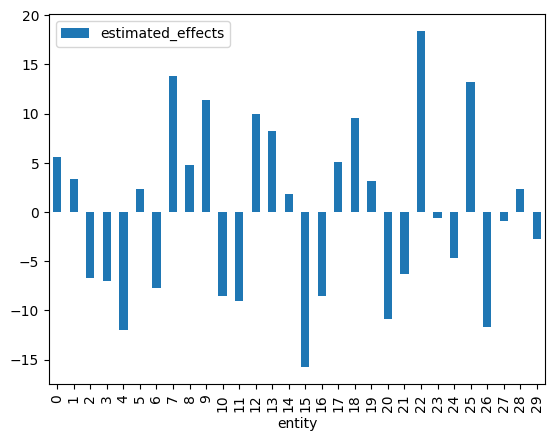

In [100]:
fitted_model.estimated_effects.reset_index().query('time == 0').plot(x='entity', y='estimated_effects', kind='bar')

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from variable_importance.memory.context_rag import ContextRAG

In [3]:
ContextRAG?

Init signature:
ContextRAG(
    collection_name: str = 'workflow_context',
    persist_directory: str = 'cache/rag_db',
    chunk_size: int = 500,
    chunk_overlap: int = 50,
    include_section_context: bool = True,
)
Docstring:     
Enhanced RAG system with chunking for better context retrieval.

Features:
- Contextual chunking that preserves document structure
- Section-aware segmentation with header context
- Code-aware chunking (preserves code blocks)
- Web search result storage with enrichment tracking
- Document upload support (PDF, text, URLs)
- Focused context for LLM queries
Init docstring:
Initialize the RAG system.

Args:
    collection_name: Name of the ChromaDB collection
    persist_directory: Directory to persist the database
    chunk_size: Size of text chunks
    chunk_overlap: Overlap between chunks
    include_section_context: Include section headers in chunks for context
File:           ~/Coding/Ideas/variable_importance/src/variable_importance/memory/context_rag.

In [4]:
rag = ContextRAG("rag-documents", persist_directory='../cache/rag_db', chunk_size=1000, chunk_overlap=100)

2025-12-09 00:02:03.991 | INFO     | variable_importance.memory.context_rag:__init__:62 - 📝 TextChunker initialized (chunk_size=1000, overlap=100, contextual=True)
2025-12-09 00:02:04.105 | INFO     | variable_importance.memory.context_rag:__init__:578 - 📚 ContextRAG initialized: rag-documents
2025-12-09 00:02:04.350 | INFO     | variable_importance.memory.context_rag:__init__:579 -    Stored documents: 10932


In [5]:
help(rag)

Help on ContextRAG in module variable_importance.memory.context_rag object:

class ContextRAG(builtins.object)
 |  ContextRAG(
 |      collection_name: str = 'workflow_context',
 |      persist_directory: str = 'cache/rag_db',
 |      chunk_size: int = 500,
 |      chunk_overlap: int = 50,
 |      include_section_context: bool = True
 |  )
 |
 |  Enhanced RAG system with chunking for better context retrieval.
 |
 |  Features:
 |  - Contextual chunking that preserves document structure
 |  - Section-aware segmentation with header context
 |  - Code-aware chunking (preserves code blocks)
 |  - Web search result storage with enrichment tracking
 |  - Document upload support (PDF, text, URLs)
 |  - Focused context for LLM queries
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      collection_name: str = 'workflow_context',
 |      persist_directory: str = 'cache/rag_db',
 |      chunk_size: int = 500,
 |      chunk_overlap: int = 50,
 |      include_section_context: bool = 

In [6]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_ollama import ChatOllama

In [7]:
model = ChatOllama(model="qwen3:8b", temperature=0, base_url="http://100.91.155.118:11434")

In [8]:
import numpy as np

In [9]:
def retrieve_context(query: str, document_type: str="", top_k: int = 3) -> list[str]:
    """Retrieve relevant context from the RAG system based on the query and document type.
    
    Args:
        query (str): The query string to search for relevant context.
        document_type (str, optional): Comma-separated string of document types (document, summary, web_result) to filter by. Defaults to "" (no filter).
        top_k (int, optional): The number of top relevant documents to retrieve. Defaults to 3.
    """
    if not document_type:
        document_type: str|None = None
    else:
        if ',' in document_type:
            document_type: list[str] = [dt.strip() for dt in document_type.split(',')]
        else:
            document_type: list[str] = [document_type.strip()]
    
    docs = rag.query_relevant_context(query, doc_types=document_type, n_results=top_k)
    if not docs:
        return ["No relevant context found."]
    return np.unique([f"Document Type: {doc.get('metadata', {}).get('type','')} Relevance: {1-doc.get('distance', 1)}\n\n{doc.get('document', '')}" for doc in docs]).tolist()
    

In [10]:
rag.get_all_documents()

[{'title': 'Market Response Models Econometric and Time Series Analysis',
  'source_type': 'pdf',
  'url': None,
  'source_path': 'Market Response Models Econometric and Time Series Analysis.pdf',
  'timestamp': '2025-12-07T20:36:58.073815',
  'content_length': 1096060,
  'chunk_count': 500,
  'workflow_id': 'rag-documents',
  'ids': ['3e9b9619de370b6699ec833e5284b0a0',
   'c9444e7d66e262b53917dc2227b60efa',
   '6b9d5c6e2aa7b76f8f535bc8d6bf3ed9',
   'b6b460392e2a9a6a543c52f605255041',
   '56762c3c26ebf71c63ed336529235cb4',
   '17c8b9209144696507120ad74e86550e',
   '398f4a70f7304a9fe4f2d3041119979e',
   '14d7b9966f9723b659ac22b1ae289821',
   '6ed5b9a1498343ea27f31d0b94322ae8',
   '5232ebcfbeee5058bbcb57d134dc3412',
   '050b6e5539dcc6620b7cda2bc429227e',
   'e2d7943b52e0f515f1531ddfea623a53',
   '87b00d5e2021993d8ef11a7df502715f',
   '83a84a1c5cb85e60a0c7e36eacf6674a',
   '2ec4dbd6710162f3d27b82c901133402',
   '449b92f50b2d66134dba01c6e059cf30',
   '6cf2766c8a7eabb2e8c42fc0dd752e36',
   

In [11]:
help(rag)

Help on ContextRAG in module variable_importance.memory.context_rag object:

class ContextRAG(builtins.object)
 |  ContextRAG(
 |      collection_name: str = 'workflow_context',
 |      persist_directory: str = 'cache/rag_db',
 |      chunk_size: int = 500,
 |      chunk_overlap: int = 50,
 |      include_section_context: bool = True
 |  )
 |
 |  Enhanced RAG system with chunking for better context retrieval.
 |
 |  Features:
 |  - Contextual chunking that preserves document structure
 |  - Section-aware segmentation with header context
 |  - Code-aware chunking (preserves code blocks)
 |  - Web search result storage with enrichment tracking
 |  - Document upload support (PDF, text, URLs)
 |  - Focused context for LLM queries
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      collection_name: str = 'workflow_context',
 |      persist_directory: str = 'cache/rag_db',
 |      chunk_size: int = 500,
 |      chunk_overlap: int = 50,
 |      include_section_context: bool = 

In [12]:
retrieve_context("hi", document_type="", top_k=6)

2025-12-09 00:02:09.456 | INFO     | variable_importance.memory.context_rag:query_relevant_context:1005 - 🔍 Retrieved 6 relevant context chunks


['Document Type: document Relevance: 0.19423043727874756\n\n--- Page 13 ---\nI\nINTRODUCTION',
 'Document Type: document Relevance: 0.1987982988357544\n\n369 14.8 Including numerical prior information 376 14.9 Bibliographic note 378 14.10 Exercises 378 15 Hierarchical linear models 381 15.1 Regression coeﬃcients exchangeable in batches 382 15.2 Example: forecasting U.S.',
 'Document Type: document Relevance: 0.19940519332885742\n\n[∞]\n259',
 'Document Type: document Relevance: 0.20083880424499512\n\n[#]\nup(u, v)dudv =',
 'Document Type: document Relevance: 0.2728826403617859\n\n,\n,\n,\n,\n,\n,']

In [13]:
rag.query_relevant_context("hi", n_results=6, doc_types=['document', 'summary'])

2025-12-09 00:02:10.090 | INFO     | variable_importance.memory.context_rag:query_relevant_context:1005 - 🔍 Retrieved 6 relevant context chunks


[{'document': ',\n,\n,\n,\n,\n,',
  'metadata': {'title': 'Market Response Models Econometric and Time Series Analysis',
   'total_chunks': 2788,
   'has_code': False,
   'chunk_type': 'prose',
   'source_path': 'Market Response Models Econometric and Time Series Analysis.pdf',
   'chunk_index': 2441,
   'content_length': 1096060,
   'workflow_id': 'rag-documents',
   'timestamp': '2025-12-07T20:36:58.073815',
   'type': 'document',
   'source_type': 'pdf',
   'chunk_size': 11,
   'original_filename': 'Market Response Models Econometric and Time Series Analysis.pdf',
   'section': 'N/A'},
  'distance': 0.7271173596382141},
 {'document': ',\n,\n,\n,\n,\n,',
  'metadata': {'source_path': 'Market Response Models Econometric and Time Series Analysis.pdf',
   'content_length': 1096060,
   'section': 'N/A',
   'chunk_index': 2441,
   'timestamp': '2025-12-07T20:36:58.073815',
   'type': 'document',
   'title': 'Market Response Models Econometric and Time Series Analysis',
   'chunk_size': 11

In [26]:
from variable_importance.memory.rag_retrieval import build_retrieval_workflow, search_with_workflow, RetrievalConfig

In [27]:
RetrievalConfig()

RetrievalConfig(max_iterations=10, max_chunks_per_query=20, max_total_chunks=100, relevance_threshold=0.2, max_consecutive_low_relevance=5, max_subtopics_to_explore=5, max_context_chars=20000, llm_model='qwen3:30b', base_url='http://100.91.155.118:11434')

In [28]:
rag.query_relevant_context("Bayes", workflow_id="rag-documents", )

2025-12-09 00:17:39.101 | INFO     | variable_importance.memory.context_rag:query_relevant_context:1005 - 🔍 Retrieved 10 relevant context chunks


[{'document': 'This is not a perfect assumption but could\nreduce the burden of modeling and computation. The practical challenges in Bayesian inference involve setting up models to estimate all\nthese probabilities from data. At that point, as shown above, Bayes’ rule can be easily\napplied to determine the implications of the model for the problem at hand.',
  'metadata': {'timestamp': '2025-12-07T20:42:12.030325',
   'workflow_id': 'rag-documents',
   'total_chunks': 5543,
   'chunk_index': 129,
   'chunk_type': 'prose',
   'source_type': 'pdf',
   'source_path': 'BDA3.pdf',
   'has_code': False,
   'original_filename': 'BDA3.pdf',
   'section': 'N/A',
   'chunk_size': 342,
   'content_length': 2113487,
   'type': 'document',
   'title': 'BDA3'},
  'distance': 0.4348936676979065},
 {'document': 'Contents Preface xiii Part I: Fundamentals of Bayesian Inference 1 1 Probability and inference 3 1.1 The three steps of Bayesian data analysis 3 1.2 General notation for statistical inferenc

In [29]:
result = await search_with_workflow(
    "How can I build a model for media measurement?", 
    rag, 
    workflow_id='rag-documents', 
    config=RetrievalConfig(
        max_chunks_per_query=5,
        max_total_chunks=100,
        relevance_threshold=0.3,
        max_context_chars=20_000,
    )
)

2025-12-09 00:17:39.119 | INFO     | variable_importance.memory.rag_retrieval.workflow:search_with_workflow:129 - 🚀 Starting RAG retrieval workflow for: How can I build a model for media measurement?...
2025-12-09 00:17:39.120 | DEBUG    | variable_importance.memory.rag_retrieval.nodes:emit_progress:61 - RAG Retrieval: 📋 Planning search queries...
2025-12-09 00:17:53.718 | DEBUG    | variable_importance.memory.rag_retrieval.nodes:emit_progress:61 - RAG Retrieval: 📋 Planned 6 queries: ['Marketing Mix Modeling statsmodels implementation', 'Multi-touch attribution model code GitHub', 'Bayesian MMM PyMC3 tutorial', 'Causal inference in advertising', 'Marketing analytics performance metrics', 'Time series analysis for ad spend optimization']
2025-12-09 00:17:53.723 | DEBUG    | variable_importance.memory.rag_retrieval.nodes:emit_progress:61 - RAG Retrieval: ✏️ Rewriting query: Marketing Mix Modeling statsmodels implementation
2025-12-09 00:18:07.100 | DEBUG    | variable_importance.memory.r

In [30]:
from rich.console import Console
from rich.markdown import Markdown
console = Console()

In [31]:
console.print(Markdown(result["context"]))

The retrieved context does not provide actionable guidance for building a media measurement model, as it consists  
solely of bibliographic references (academic citations) rather than methodological instructions, code examples, or 
practical frameworks. Below is a clear synthesis addressing your query:                                            

                                       Key Assessment of Retrieved Context:                                        

 1 Source Type & Relevance:                                                                                        
    • All entries are academic bibliographies (e.g., Arora 1979, Riskey 1997, Assmus 1981) referencing studies on  
      advertising elasticity, causality, and media effects.                                                        
    • No practical guidance is included (e.g., no data pipelines, model architectures, or software tools).         
 2 Why This Context Fails to Answer Your Query:                                                                    
    • The citations discuss theoretical concepts (e.g., "How Promotion Elasticities Change," "How Advertising      
      Works") but do not explain how to build a model.                                                             
    • Example: Riskey (1997) analyzes advertising effectiveness in industry, but provides no implementation steps. 
    • The context lacks code, datasets, or step-by-step workflows required for model development.                  
 3 Critical Gap Identified:                                                                                        
   ▌ The retrieved sources are literature references, not instructional material. To build a media measurement     
   ▌ model, you would need:                                                                                        
   ▌  • Data sources (e.g., ad spend, audience metrics, sales data)                                                
   ▌  • Model types (e.g., attribution models, time-series forecasting, causal inference)                          
   ▌  • Tools (e.g., Python/R libraries like scikit-learn, TensorFlow, or marketing-specific platforms like        
   ▌    Google Analytics 360)                                                                                      
   ▌  • Validation methods (e.g., holdout testing, incrementality measurement)                                     

                                              Recommended Next Steps:                                              

 1 Consult practical resources instead of bibliographies:                                                          
    • Textbooks: "Marketing Analytics" (Farris et al.) or "Data-Driven Marketing" (Chaffey).                       
    • Tools: Explore Google’s Attribution Modeling Guide or Adobe Analytics documentation.                         
    • Code examples: Search GitHub for "media mix modeling" or "advertising attribution Python".                   
 2 Key concepts from the bibliography (for context, not implementation):                                           
    • Promotion elasticity (Arora 1979): Measures how sales respond to ad spend changes.                           
    • Causality tests (Roberts & Nord 1988): Critical for isolating media impact from confounding factors.         
    • Time-varying models (Riddington 1993): Useful for dynamic media environments.                                

                                                    Conclusion:                                                    

The retrieved context is insufficient to answer "How can I build a model for media measurement?" It only lists     
academic papers that study media measurement—not how to build it. To proceed, prioritize practical guides, code    
repositories, or industry case studies over bibliographies. For example, a media measurement model typically       
involves:                                         

In [ ]:
agent = create_agent(
    model,
    tools=[]
)

Signature:
create_agent(
    model: 'str | BaseChatModel',
    tools: 'Sequence[BaseTool | Callable | dict[str, Any]] | None' = None,
    *,
    system_prompt: 'str | None' = None,
    middleware: 'Sequence[AgentMiddleware[StateT_co, ContextT]]' = (),
    response_format: 'ResponseFormat[ResponseT] | type[ResponseT] | None' = None,
    state_schema: 'type[AgentState[ResponseT]] | None' = None,
    context_schema: 'type[ContextT] | None' = None,
    checkpointer: 'Checkpointer | None' = None,
    store: 'BaseStore | None' = None,
    interrupt_before: 'list[str] | None' = None,
    interrupt_after: 'list[str] | None' = None,
    debug: 'bool' = False,
    name: 'str | None' = None,
    cache: 'BaseCache | None' = None,
) -> 'CompiledStateGraph[AgentState[ResponseT], ContextT, _InputAgentState, _OutputAgentState[ResponseT]]'
Docstring:
Creates an agent graph that calls tools in a loop until a stopping condition is met.

For more details on using `create_agent`,
visit the [Agents](https:/

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [138]:
n = 156
x1, x2, x3 = np.random.lognormal(size=n), np.random.lognormal(size=n), np.random.lognormal(size=n)

In [139]:
w1_, w2_ = np.meshgrid(np.linspace(.1,1.9,400), np.linspace(.1,1.9,400))
w3_ = (np.sum(x1) + np.sum(x2) + np.sum(x3) - w1_*np.sum(x1)-w2_*np.sum(x2)) / np.sum(x3)

In [160]:
alpha = .88
beta = .00001
w1 = w1_[120, 240]
w2 = w2_[120, 240]
w3 = w3_[120, 240]
max_val = np.max(w1*x1 + w2*x2 + w3*x3)
y = (beta**(alpha**((w1*x1 + w2*x2 + w3*x3)/max_val * 100))-beta)  + np.random.normal(0, .1, size=n)

In [164]:
def calc_weights(w1, w2):
    w3 = (np.sum(x1) + np.sum(x2) + np.sum(x3) - w1*np.sum(x1)-w2*np.sum(x2)) / np.sum(x3)
    return w3

np.float64(0.9999999999999999)

In [162]:
def loglikelihood(w1, w2):
    w3 = (np.sum(x1) + np.sum(x2) + np.sum(x3) - w1*np.sum(x1)-w2*np.sum(x2)) / np.sum(x3)
    y_pred = (beta**(alpha**((w1*x1 + w2*x2 + w3*x3)/(max_val) * 100))-beta)
    residuals = y - y_pred
    ll = -0.5 * np.sum((residuals)**2)
    return ll

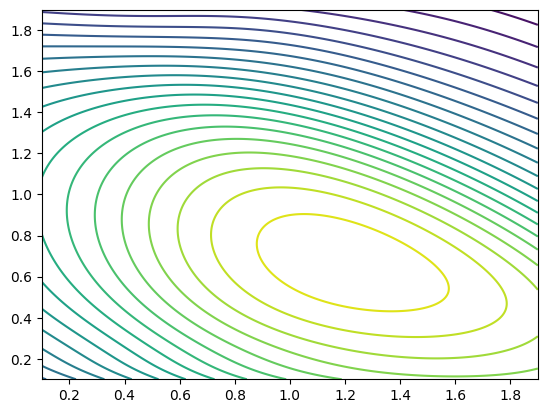

In [168]:
plt.contour(w1_, w2_, np.vectorize(loglikelihood)(w1_, w2_), levels=25)